# Day 13 — 综合实战：数据获取→可视化全流程

**目标**：把 Day10-12 串成完整流水线

- ☀️ 下午：4 张多股对比图
- 🌙 晚上：200 字观察总结

In [3]:
# ===== 基础设置 =====
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec

font_manager.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 环境就绪')

✅ 环境就绪


In [4]:
# --- 加载所有本地股票数据 ---
import os

files = [f for f in os.listdir('../data') if f.endswith('.csv')]
print('可用股票:', files)

# 全部读进来
stocks = {}
for f in files:
    name = f.replace('.csv', '')
    df = pd.read_csv(f'../data/{f}')
    df['日期'] = pd.to_datetime(df['日期'])
    df = df.set_index('日期').sort_index()
    df['收益率'] = df['收盘'].pct_change()
    stocks[name] = df

print(f'\n已加载 {len(stocks)} 只股票：')
for name, df in stocks.items():
    print(f'  {name}: {len(df)} 行, {df.index[0].date()} ~ {df.index[-1].date()}')

# 合并所有股票的收盘价到一个表（用于相关性分析）
close_df = pd.DataFrame({name: df['收盘'] for name, df in stocks.items()})
print(f'\n合并收盘价表: {close_df.shape[0]} 行 × {close_df.shape[1]} 列')
close_df.tail(3)

可用股票: ['招商银行.csv', '恒瑞医药.csv', '比亚迪.csv', '茅台.csv', '海康威视.csv']

已加载 5 只股票：
  招商银行: 250 行, 2025-07-01 ~ 2026-07-10
  恒瑞医药: 250 行, 2025-07-01 ~ 2026-07-10
  比亚迪: 250 行, 2025-07-01 ~ 2026-07-10
  茅台: 250 行, 2025-07-01 ~ 2026-07-10
  海康威视: 250 行, 2025-07-01 ~ 2026-07-10

合并收盘价表: 250 行 × 5 列


,招商银行,恒瑞医药,比亚迪,茅台,海康威视
日期,,,,,
2026-07-08,36.94,54.01,87.80,1199.30,34.35
2026-07-09,36.55,55.61,86.87,1182.19,35.39
2026-07-10,36.88,55.75,90.00,1204.98,34.45


findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight normal, now using 300.


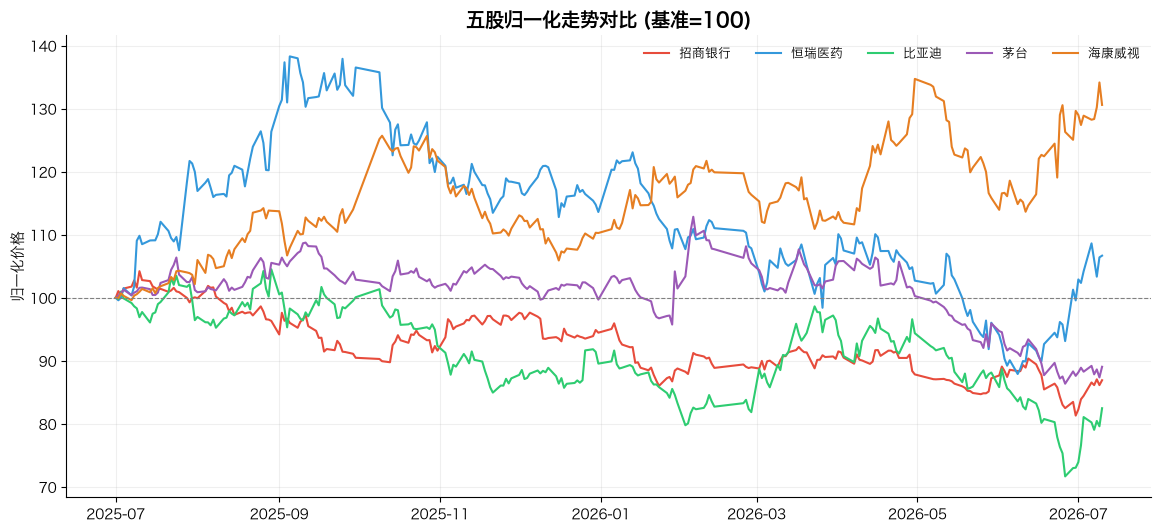

In [5]:
# 图1：五股归一化走势对比
# 每只股票「如果第一天是100元，现在值多少」

normalized = close_df / close_df.iloc[0] * 100   # 全部除以各自第一天的价×100

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#e67e22']
for i, name in enumerate(normalized.columns):
    ax.plot(normalized.index, normalized[name], color=colors[i], lw=1.5, label=name)

ax.axhline(y=100, color='gray', lw=0.8, ls='--')   # 基准线
ax.set_title('五股归一化走势对比 (基准=100)', fontsize=14, fontweight='bold')
ax.legend(ncol=5, frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)
ax.set_ylabel('归一化价格')
plt.show()

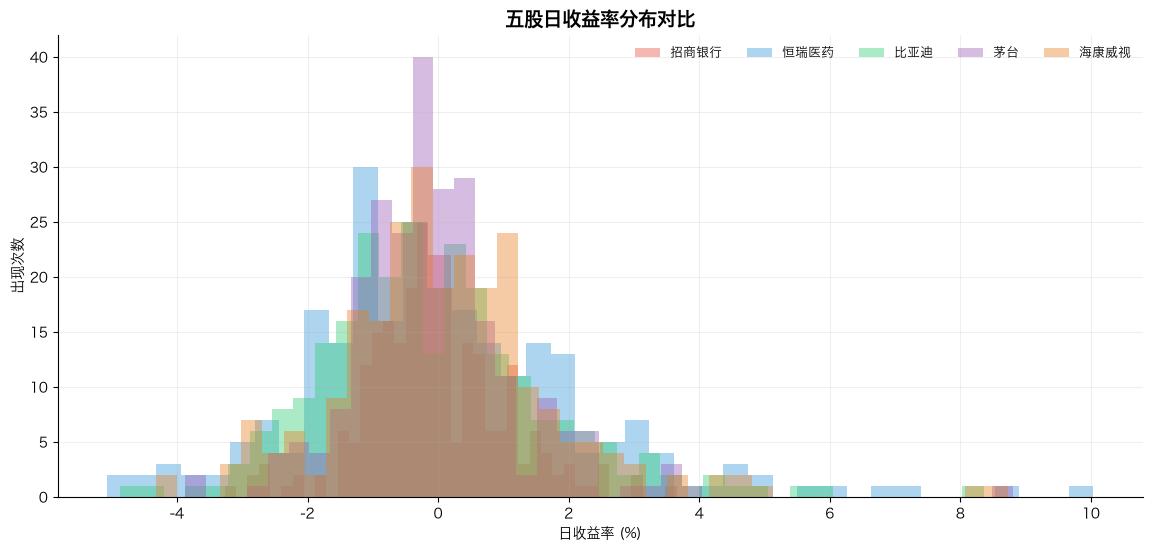

In [6]:
# 图2：五股日收益率分布对比
returns = close_df.pct_change().dropna() * 100   # 日收益率(%)

fig, ax = plt.subplots(figsize=(14, 6))
for i, name in enumerate(returns.columns):
    ax.hist(returns[name], bins=40, alpha=0.4, color=colors[i], label=name)

ax.set_title('五股日收益率分布对比', fontsize=14, fontweight='bold')
ax.set_xlabel('日收益率 (%)'); ax.set_ylabel('出现次数')
ax.legend(ncol=5, frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)
plt.show()

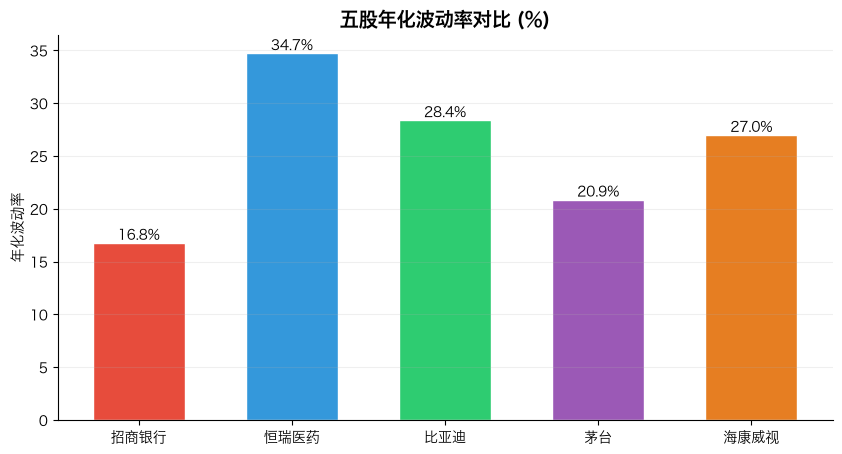

In [7]:
# 图3：五股年化波动率对比
vol = returns.std() * np.sqrt(252)   # 日波动×√252=年化波动率(%)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(vol)), vol.values, color=colors, edgecolor='white', width=0.6)
ax.set_xticks(range(len(vol)))
ax.set_xticklabels(vol.index)
ax.set_title('五股年化波动率对比 (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('年化波动率')
# 在柱子上标数值
for bar, val in zip(bars, vol.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.1f}%', ha='center', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2, axis='y')
plt.show()

findfont: Failed to find font weight normal, now using 300.


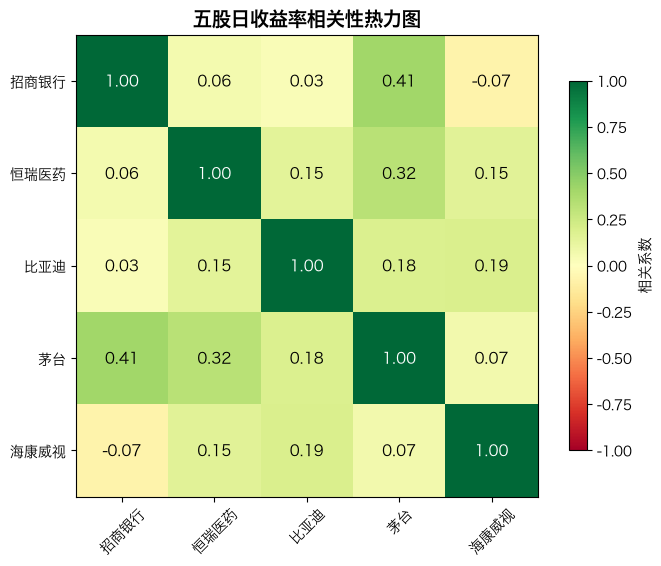

In [8]:
# 图4：相关性热力图（matplotlib 原生版，不依赖 seaborn）
corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)

# 在每个格子里写相关系数
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
                ha='center', va='center', fontsize=11,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')

ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
ax.set_title('五股日收益率相关性热力图', fontsize=14, fontweight='bold')
fig.colorbar(im, ax=ax, shrink=0.8, label='相关系数')
plt.show()

In [11]:
# 精确数据：每只股票过去一年的总收益和波动率
total_return = (close_df.iloc[-1] / close_df.iloc[0] - 1) * 100
volatility = returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    '总收益(%)': total_return.round(1),
      '年化波动(%)': volatility.round(1)
  })
  summary.sort_values('总收益(%)', ascending=False)

IndentationError: unexpected indent (863318728.py, line 9)